In [1]:
import os
import argparse
import numpy as np
from tqdm import tqdm
import os.path as osp
from copy import deepcopy
from easydict import EasyDict as edict
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import albumentations as A

from src.cf_methods import c3lt 
from src.datasets import DatasetBuilder

from src.models.classifiers import build_resnet50
from src.evaluation.local_instability import perturb_sample
from src.utils import extract_factual_instances, filter_valid_factuals
from src.utils import seed_everything, get_config, load_model_weights
from src.utils import evaluate_classification_model, plot_boxplot

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
I0000 00:00:1775674638.631669    3714 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
seed_everything()

In [3]:
import sys
sys.argv = ['']

In [4]:
config_path = r'/teamspace/studios/this_studio/CF-Robustness-Benchmark/configs/c3lt_derma_multi.yaml'
config = get_config(config_path)
ds_builder = DatasetBuilder(config)
ds_builder.setup()
train_loader, val_loader, test_loader = ds_builder.get_dataloaders()

imgs = ds_builder.train_dataset.data.imgs  # (N, H, W, 3), uint8 [0, 255]
dataset_mean = imgs.mean(axis=(0, 1, 2)) / 255.0   # per-channel mean
dataset_std = imgs.std(axis=(0, 1, 2)) / 255.0 

gan_mean = [0.5, 0.5, 0.5]
gan_std = [0.5, 0.5, 0.5]

train_transform = A.Compose([
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=gan_mean, std=gan_std, max_pixel_value=255.0),
])

val_transform = A.Compose([
    A.Normalize(mean=gan_mean, std=gan_std, max_pixel_value=255.0),
])

train_loader.dataset.transform = train_transform
val_loader.dataset.transform = val_transform
test_loader.dataset.transform = val_transform

In [5]:
# Create an args object to pass all relevant parameters 
weights_dir = '/teamspace/studios/this_studio/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/derma'

log_path ='/teamspace/studios/this_studio/CF-Robustness-Benchmark/cf_output/derma/c3lt_multi'

args = c3lt.args.init_parser()
args.data_name = config.data.name
args.dataset_mean = dataset_mean
args.dataset_std = dataset_std
args.channels = 3
args.img_size = 64
args.device = "cuda" if torch.cuda.is_available() else "cpu"
args.log_path = log_path
args.gen_path = osp.join(weights_dir, 'gen_epoch_100.pth')
args.disc_path = osp.join(weights_dir, 'discr_epoch_100.pth')
args.enc_path = osp.join(weights_dir, 'encoder_derma_4_new.pth')
args.cls_path = config.classifier.checkpoints_path
args.dataset_path = config.data_dir
args.cls_1 = 3 # 0
args.cls_2 = 2  # 4
# args.num_classes = 2
args.classifier_name = config.classifier.name
args.cls_lightning_used = config.classifier.lightning_used
args.classifier_args={**config.classifier.args, 
                    'num_classes': config.data.num_classes,
}
args.ndf = 64
args.epochs = 50
args.n_steps = 3
args.alpha = 0.05    # was 0.1
args.beta = 0.05     # was 0.1 — this is the key change, reduce 10x
args.gamma = 0.0     # disable adversarial loss entirely for now — at 2.09 it's noise
# args.kappa = 1.0    # if you stay with hinge loss, increase margin
args.cls_type = 'bce'
args.norm_reg_weight = 0.5  # new soft norm constraint
args.extracted_layers = ['layer1',  'layer2', 'layer3', 'layer4']
args.output = '/teamspace/studios/this_studio/CF-Robustness-Benchmark/cf_output/derma/c3lt_multi/results'

In [6]:
os.makedirs(args.output, exist_ok=True)
os.makedirs(osp.join(args.output, 'snaps'), exist_ok=True)

In [7]:
def dataloader_pair(args, dataset, is_train):
    """
        returns dataloaders for a class pair.

    :param args:
    :param is_train:
    :return:
    """
    dataset_1 = deepcopy(dataset)
    dataset_2 = deepcopy(dataset)

    # extract samples only of class 1
    idx_1 = dataset_1.data.labels.ravel() == args.cls_1
    dataset_1.data.imgs = dataset_1.data.imgs[idx_1]
    dataset_1.data.labels = dataset_1.data.labels[idx_1]

    # extract samples only of class 2
    idx_2 = dataset_2.data.labels.ravel() == args.cls_2
    dataset_2.data.imgs = dataset_2.data.imgs[idx_2]
    dataset_2.data.labels = dataset_2.data.labels[idx_2]

    dataloader_1 = DataLoader(dataset_1, 
                              batch_size=args.batch_size,
                              shuffle=is_train, 
                              pin_memory=True, 
                              drop_last=False)
    dataloader_2 = DataLoader(dataset_2, 
                              batch_size=args.batch_size,
                              shuffle=is_train, 
                              pin_memory=True, 
                              drop_last=False)

    return  dataloader_1, dataloader_2

In [8]:
dataloaders = dataloader_pair(args, ds_builder.train_dataset, is_train=True)
dataloaders_test = dataloader_pair(args, ds_builder.test_dataset, is_train=False)

In [9]:
cls1_imgs, cls1_labels = next(iter(dataloaders_test[0]))
cls2_imgs, cls2_labels = next(iter(dataloaders_test[1]))

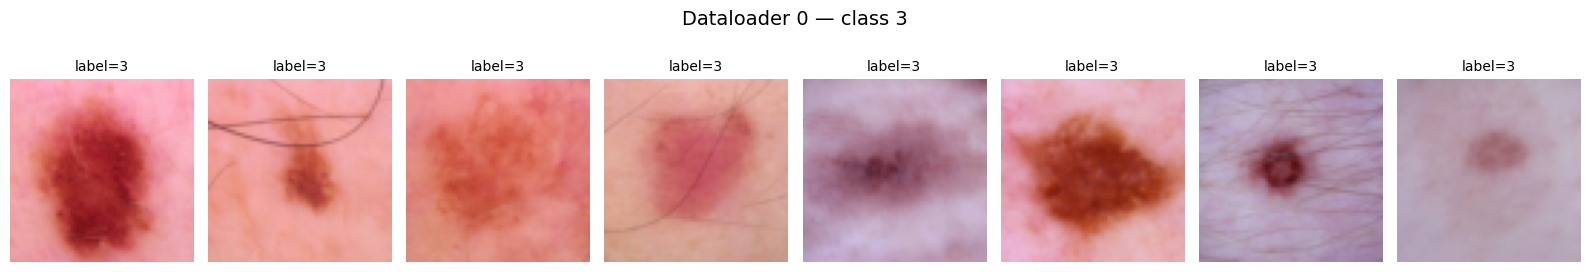

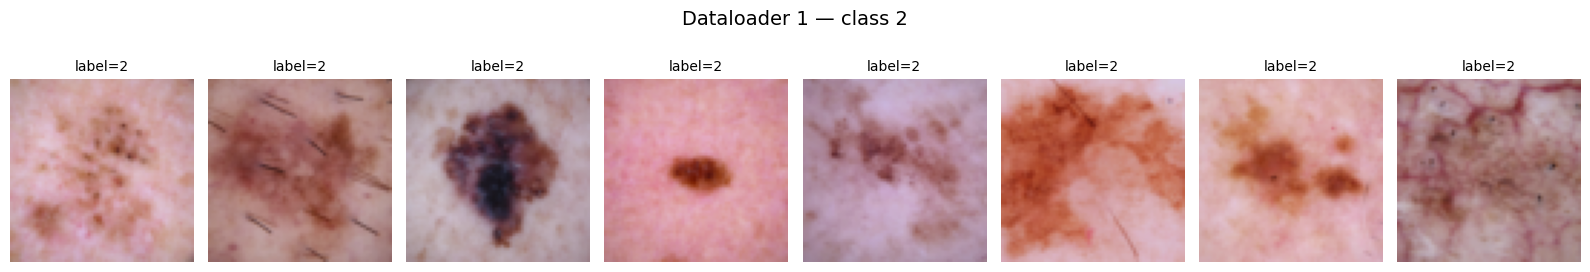

In [10]:
def denorm(tensor):
    """Denormalize from [-1, 1] to [0, 1] (reverses GAN normalization)."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

def show_batch(imgs, labels, title, n=8):
    imgs = denorm(imgs[:n])  # (N, C, H, W)
    fig, axs = plt.subplots(1, n, figsize=(2 * n, 3))
    for i in range(n):
        img = imgs[i].permute(1, 2, 0).numpy()  # (H, W, C)
        axs[i].imshow(img)
        axs[i].set_title(f"label={labels[i].item()}", fontsize=10)
        axs[i].axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_batch(cls1_imgs, cls1_labels, title=f"Dataloader 0 — class {args.cls_1}")
show_batch(cls2_imgs, cls2_labels, title=f"Dataloader 1 — class {args.cls_2}")

In [11]:
# from src.models.classifiers import build_resnet50
# from src.utils.generic_utils import load_model_weights
# from src.cf_methods.c3lt.helper import RenormalizeGANToClassifier

# cls = build_resnet50(**args.classifier_args)
# load_model_weights(cls, weights_path=args.cls_path)

# renorm = RenormalizeGANToClassifier(args.dataset_mean, args.dataset_std, device='cpu')
# torch.argmax(cls(renorm(cls2_imgs).to(torch.float32)), axis=-1)

# Training

In [164]:
c3lt.train.train_c3lt(args, [dataloaders, dataloaders_test])

Generator loaded!
Discriminator loaded!
Encoder loaded!
Classifier loaded!

Training Starts...

[Epoch 0/50] [TRAIN Loss: 2.93511]

EVAL [CLS loss: 0.2163]  [PROX loss: 0.0354]  [CYC Loss: 0.5267]  [ADV loss: 2.5743]  [EVAL loss: 0.2444] 
EVAL [COUT: 1.0816]  [Validity: 93.67 %]  [Proximity: 0.9976]

[Epoch 1/50] [TRAIN Loss: 0.40786]
[Epoch 2/50] [TRAIN Loss: 0.25949]
[Epoch 3/50] [TRAIN Loss: 0.19664]
[Epoch 4/50] [TRAIN Loss: 0.15749]
[Epoch 5/50] [TRAIN Loss: 0.13665]
[Epoch 6/50] [TRAIN Loss: 0.11529]
[Epoch 7/50] [TRAIN Loss: 0.10416]
[Epoch 8/50] [TRAIN Loss: 0.09604]
[Epoch 9/50] [TRAIN Loss: 0.08952]
[Epoch 10/50] [TRAIN Loss: 0.08151]

EVAL [CLS loss: 0.0137]  [PROX loss: 0.0390]  [CYC Loss: 0.4314]  [ADV loss: 2.0316]  [EVAL loss: 0.0372] 
EVAL [COUT: 2.5130]  [Validity: 100.00 %]  [Proximity: 1.3731]

[Epoch 11/50] [TRAIN Loss: 0.07754]
[Epoch 12/50] [TRAIN Loss: 0.07490]
[Epoch 13/50] [TRAIN Loss: 0.07031]
[Epoch 14/50] [TRAIN Loss: 0.06587]
[Epoch 15/50] [TRAIN Loss: 0.06

In [165]:
from src.cf_methods.c3lt.helper import forward_map, nonlinear_map_step
from src.cf_methods.c3lt.modules import NLMappingConv
from src.cf_methods.c3lt.helper import load_pretrained_encoder, load_pretrained_gan

In [166]:
classifier = build_resnet50(**args.classifier_args).to(args.device)
load_model_weights(classifier, weights_path=args.cls_path, device=args.device)

gen, _  =  load_pretrained_gan(args)
gen  = gen.to(args.device)
encoder  = load_pretrained_encoder(args).to(args.device)

Generator loaded!
Discriminator loaded!
Encoder loaded!


In [167]:
mapper_path = '/teamspace/studios/this_studio/CF-Robustness-Benchmark/cf_output/derma/c3lt_multi/results_3_2_new_enc/snaps/map_3_to_2_50.pt'
g = NLMappingConv(args.latent_dim).to(args.device)
load_model_weights(g, weights_path=mapper_path)

In [169]:
sample_images = next(iter(dataloaders[0]))[0]

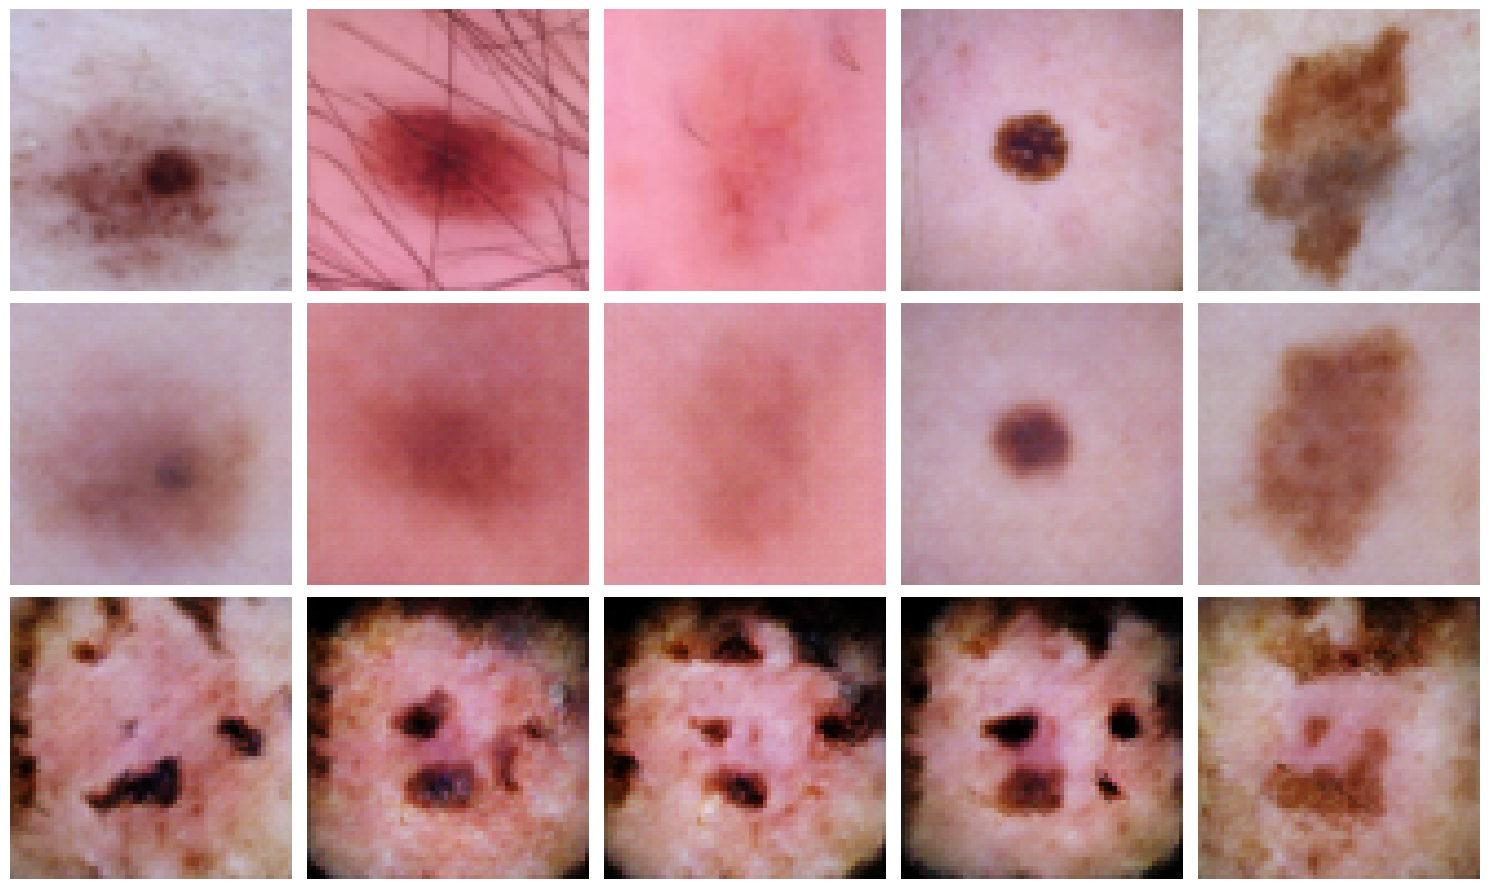

In [170]:
with torch.no_grad():
    imgs = sample_images[:5].to(device)
    path_imgs, _ = forward_map(imgs, encoder, gen, g, args)
    recon = path_imgs[0]
    cfes = path_imgs[-1]

fig, axs = plt.subplots(3, 5, figsize=(15, 9))
for i in range(5):
    # All three are in [-1, 1], apply same denorm
    inp = (imgs[i].cpu()  * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()
    rec = (recon[i].cpu() * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()
    cfe = (cfes[i].cpu()  * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()
    
    axs[0, i].imshow(inp)
    axs[1, i].imshow(rec)
    axs[2, i].imshow(cfe)
    
    for r in range(3):
        axs[r, i].axis('off')

axs[0, 0].set_ylabel('Input', fontsize=14)
axs[1, 0].set_ylabel('Recon', fontsize=14)
axs[2, 0].set_ylabel('CFE', fontsize=14)
plt.tight_layout()
plt.show()

z shape: torch.Size([5, 100, 1, 1])
recon range: -0.715 to 0.800


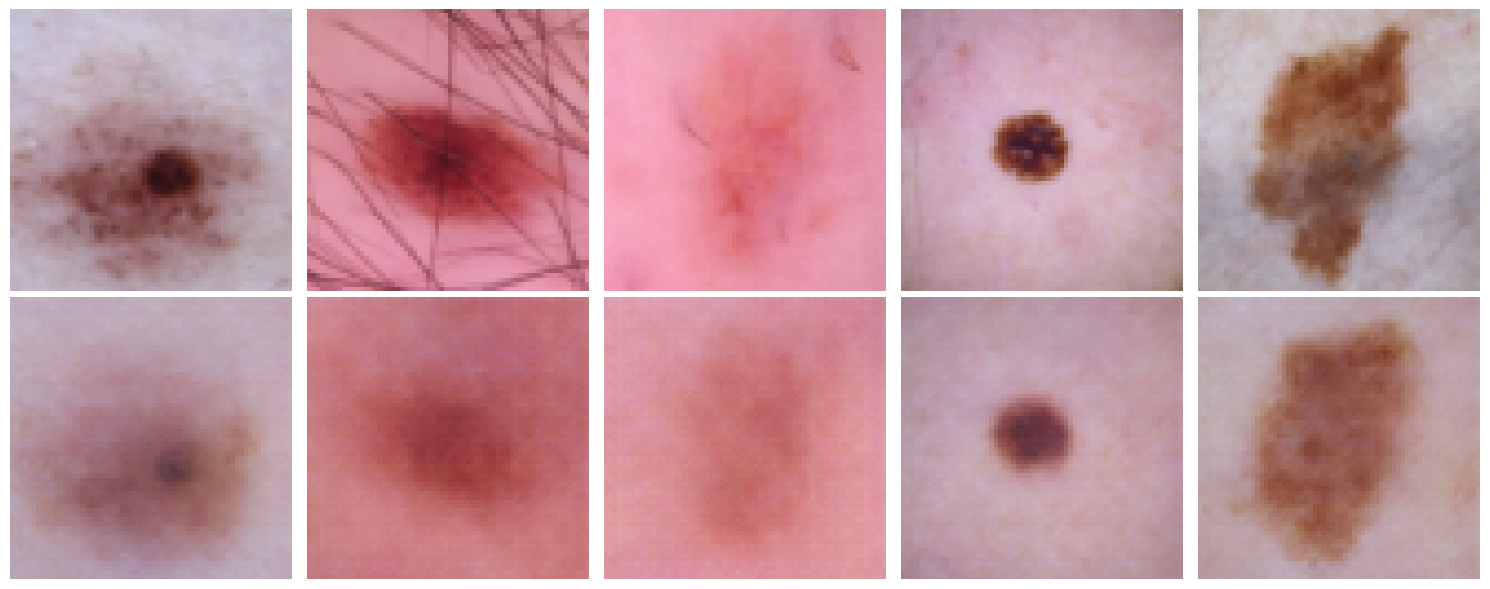

In [171]:
with torch.no_grad():
    imgs = sample_images[:5].to(device)
    z = encoder(imgs)
    recon = gen(z)
    
    print(f"z shape: {z.shape}")
    print(f"recon range: {recon.min():.3f} to {recon.max():.3f}")
    
    fig, axs = plt.subplots(2, 5, figsize=(15, 6))
    for i in range(5):
        axs[0, i].imshow((imgs[i].cpu() * 0.5 + 0.5).clamp(0,1).permute(1,2,0).numpy())
        axs[1, i].imshow((recon[i].cpu() * 0.5 + 0.5).clamp(0,1).permute(1,2,0).numpy())
        axs[0, i].axis('off')
        axs[1, i].axis('off')
    axs[0, 0].set_ylabel('Input', fontsize=14)
    axs[1, 0].set_ylabel('Recon', fontsize=14)
    plt.tight_layout()
    plt.show()

In [172]:
print(f"sample_images range: {sample_images.min():.3f} to {sample_images.max():.3f}")


sample_images range: -1.000 to 1.000


In [173]:
with torch.no_grad():
    z = encoder(sample_images.to(device))
    out_z = nonlinear_map_step(z, g, args.n_steps)
    
    z_orig_norm = torch.norm(z.view(z.shape[0], -1), dim=1).mean()
    z_final_norm = torch.norm(out_z[-1].view(z.shape[0], -1), dim=1).mean()
    
    print(f"Original norm: {z_orig_norm:.3f}")
    print(f"Mapped norm: {z_final_norm:.3f}")
    
    # Also check generator output range
    cf = gen(out_z[-1])
    print(f"CFE range: min={cf.min():.3f}, max={cf.max():.3f}")

Original norm: 9.805
Mapped norm: 9.816
CFE range: min=-1.000, max=0.897


In [174]:
with torch.no_grad():
    path_imgs, _ = forward_map(sample_images[:1].to(device), encoder, gen, g, args)
    cfe = path_imgs[-1][0]
    
    print(f"Shape: {cfe.shape}")
    print(f"Per-channel min: {cfe[0].min():.3f}, {cfe[1].min():.3f}, {cfe[2].min():.3f}")
    print(f"Per-channel max: {cfe[0].max():.3f}, {cfe[1].max():.3f}, {cfe[2].max():.3f}")
    print(f"Per-channel mean: {cfe[0].mean():.3f}, {cfe[1].mean():.3f}, {cfe[2].mean():.3f}")
    
    # Also check the reconstruction (step 0)
    recon = path_imgs[0][0]
    print(f"\nRecon shape: {recon.shape}")
    print(f"Recon range: {recon.min():.3f} to {recon.max():.3f}")
    print(f"Recon per-channel mean: {recon[0].mean():.3f}, {recon[1].mean():.3f}, {recon[2].mean():.3f}")

Shape: torch.Size([3, 64, 64])
Per-channel min: -0.962, -0.984, -0.987
Per-channel max: 0.632, 0.456, 0.554
Per-channel mean: 0.287, -0.082, -0.106

Recon shape: torch.Size([3, 64, 64])
Recon range: -0.567 to 0.572
Recon per-channel mean: 0.375, 0.117, 0.199


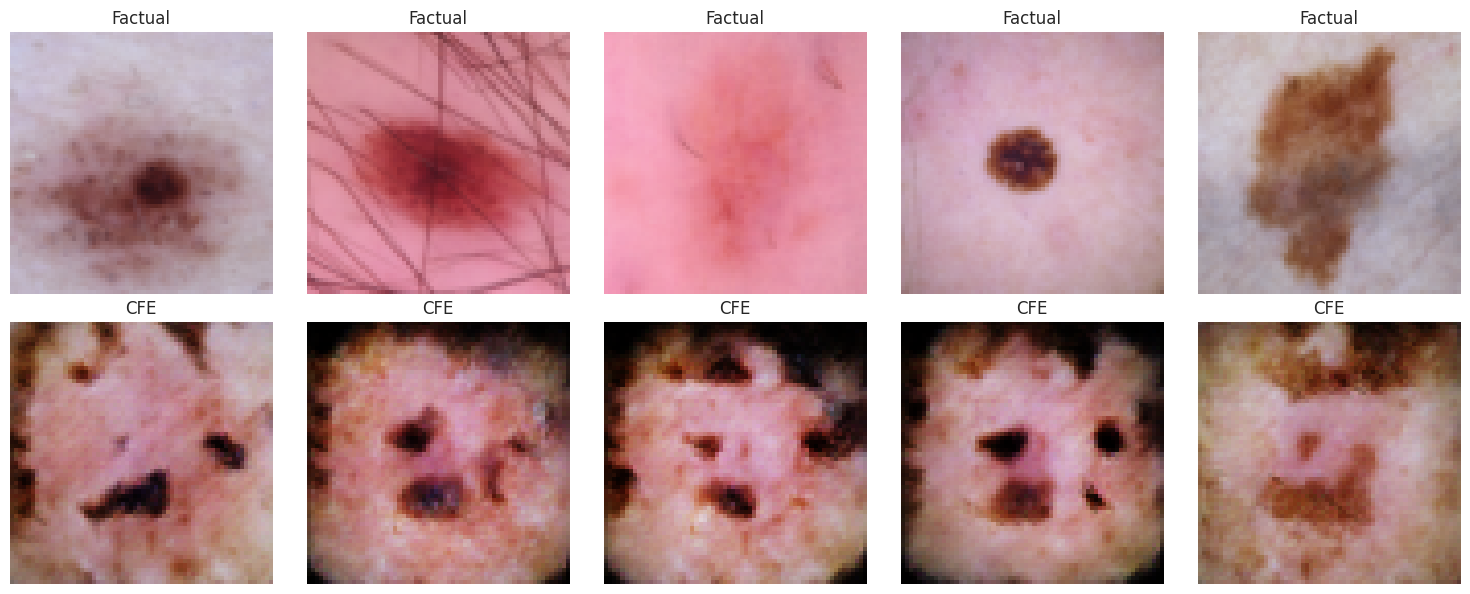

In [175]:
with torch.no_grad():
    path_imgs, _ = forward_map(sample_images[:5].to(device), encoder, gen, g, args)
    
    fig, axs = plt.subplots(2, 5, figsize=(15, 6))
    for i in range(5):
        # Factual
        f_img = (sample_images[i].cpu() * 0.5 + 0.5).clamp(0, 1)
        axs[0, i].imshow(f_img.permute(1, 2, 0).numpy())
        axs[0, i].set_title('Factual')
        axs[0, i].axis('off')
        
        # CFE
        c_img = (path_imgs[-1][i].cpu() * 0.5 + 0.5).clamp(0, 1)
        axs[1, i].imshow(c_img.permute(1, 2, 0).numpy())
        axs[1, i].set_title('CFE')
        axs[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

In [111]:
with torch.no_grad():
    # Take a batch of real images from class 1
    sample = next(iter(dataloaders[0]))[0][:5].to(args.device)
    
    logits = classifier(sample)
    print(f"Classifier output range: min={logits.min():.3f}, max={logits.max():.3f}")
    print(f"Classifier output sum per row: {logits.softmax(dim=1).sum(dim=1)[:3]}")
    print(f"Sample row: {logits[0]}")
    
    # Now check counterfactuals
    path_imgs, latents = forward_map(sample, encoder, gen, g, args)
    cf_imgs = path_imgs[-1]
    cf_logits = classifier(cf_imgs)
    print(f"\nCF logits: {cf_logits[0]}")
    print(f"CF preds: {cf_logits.argmax(dim=1)}")
    print(f"Target class: {args.cls_2}")

Classifier output range: min=-6.322, max=3.995
Classifier output sum per row: tensor([1., 1., 1.], device='cuda:0')
Sample row: tensor([ 0.5855, -1.1905, -1.4450,  0.8764], device='cuda:0')

CF logits: tensor([-6.0244,  0.2674,  2.6180,  2.5513], device='cuda:0')
CF preds: tensor([2, 3, 2, 2, 0], device='cuda:0')
Target class: 2


# Inference

In [12]:
import pickle
import torch.nn.functional as F
from src.cf_methods.c3lt import C3LTModel
from src.evaluation.local_instability import perturb_sample
from src.evaluation.local_instability import calculate_sparsity, calculate_ssim
from src.utils.visualization import plot_boxplot
from src.cf_methods.c3lt.helper import RenormalizeGANToClassifier


In [13]:
repo_path = '/teamspace/studios/this_studio/CF-Robustness-Benchmark'
save_dir = osp.join(repo_path, 'cf_output/derma/c3lt_multi')
save_dir

'/teamspace/studios/this_studio/CF-Robustness-Benchmark/cf_output/derma/c3lt_multi'

In [14]:
target_class = 4
target_class_ind = 2
# initial_classes = [0]
initial_classes = [0, 1, 3]
# initial_classes = [3]
device = args.device

# mappers = {0: osp.join(repo_path, f'cf_output/derma/c3lt_multi/results/snaps/map_0_to_{target_class_ind}_50.pt'),}
mappers = {0: osp.join(repo_path, f'cf_output/derma/c3lt_multi/results_0_{target_class_ind}_new_enc/snaps/map_0_to_{target_class_ind}_50.pt'),
           1: osp.join(repo_path, f'cf_output/derma/c3lt_multi/results_1_{target_class_ind}_new_enc/snaps/map_1_to_{target_class_ind}_50.pt'),
           3: osp.join(repo_path, f'cf_output/derma/c3lt_multi/results_3_{target_class_ind}_new_enc/snaps/map_3_to_{target_class_ind}_50.pt')}

# mappers = {3: osp.join(repo_path, f'cf_output/{config.data.name}/c3lt_multi/results_6_4/snaps/map_3_to_{target_class_ind}_100.pt')}


In [15]:
expl_model = C3LTModel(args, task='multiclass')
expl_model.setup_model(mapper_weights_path=mappers)
baseline_classifier = expl_model.classifier

renorm = RenormalizeGANToClassifier(dataset_mean=args.dataset_mean,
                                            dataset_std=args.dataset_std,  
                                            device=args.device
                                        )

Classifier loaded!
Generator loaded!
Discriminator loaded!
Encoder loaded!


In [16]:
def denormalize(img_tensor, mean, std):
    """Reverse ImageNet normalization for visualization. 
    Input: (C, H, W) tensor."""
    mean = torch.tensor(mean, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, device=img_tensor.device).view(3, 1, 1)
    return torch.clamp(img_tensor * std + mean, 0, 1)

In [17]:
def normalize(img_tensor, mean, std):
    """
    Apply normalization to an image tensor.
    Input: (C, H, W) tensor in range [0, 1].
    Output: Normalized tensor centered around 0.
    """
    # Convert lists to tensors and reshape for broadcasting: (C, 1, 1)
    mean = torch.tensor(mean, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, device=img_tensor.device).view(3, 1, 1)
    return (img_tensor - mean) / std

In [18]:
images, labels = next(iter(test_loader))
print(images.min(), images.max())
denorm_images = renorm(images.to(device))
print(denorm_images.min(), denorm_images.max())
denorm_images = denorm(images.to(device))
# denorm_images = denormalize(images.to(device), args.dataset_mean, args.dataset_std)
print(denorm_images.min(), denorm_images.max())
# norm_images = normalize(denorm_images, mean, std)
# print(norm_images.min(), norm_images.max())

tensor(-0.9922) tensor(1.)
tensor(-5.0456) tensor(2.8488)
tensor(0.0039) tensor(1.)


In [32]:
factuals, labels = extract_factual_instances(test_loader, initial_classes)
print('Number of instances before filtering:' ,  factuals.shape[0])
print(factuals.min(), factuals.max())
renorm_factuals = renorm(factuals.to(device))
# print(renorm_factuals.min(), renorm_factuals.max())

# classifier = classifier.to(device)
predictions = torch.argmax(baseline_classifier(renorm_factuals.to(device)), axis=1).detach().cpu()
valid_indices = np.where(predictions == labels)[0]
factuals = factuals[valid_indices]
labels = labels[valid_indices]
print('Number of instances after filtering:',  factuals.shape[0])


Number of instances before filtering: 544
tensor(-1.) tensor(1.)


Number of instances after filtering: 377


## Local Instability

In [33]:
noise_levels =  [0.005, 0.01, 0.015, 0.02, 0.025]

In [34]:
from functools import reduce

n = 100
factuals_pert = {}    
indices_pert = {}

for noise in noise_levels:
    factuals_array = denorm(factuals.cpu())
    # print('factuals', factuals_array.min(), factuals_array.max())
    factuals_pert[noise] = perturb_sample(factuals_array, n_samples=1, epsilon=noise, 
                                        type='uniform', channels_first=True).squeeze(1)
    # print(factuals_pert[noise].min(), factuals_pert[noise].max())
    pert_sample = torch.Tensor(factuals_pert[noise])

    # Check whether perturbed instances lead to the same class prediction
    norm_pert = renorm(pert_sample.to(device))
    # print('norm factuals  pert', norm_pert.min(), norm_pert.max(), norm_pert.shape)

    predictions = torch.argmax(baseline_classifier(norm_pert), axis=1).detach().cpu()
    # print(predictions.shape)
    indices = np.where(predictions == labels)[0]
    print(f'Number of valid perturbed factuals for the added noise level {noise}: ', indices.shape[0])
    pert_sample = pert_sample[indices] 
    indices_pert[noise] = indices

Number of valid perturbed factuals for the added noise level 0.005:  84
Number of valid perturbed factuals for the added noise level 0.01:  84
Number of valid perturbed factuals for the added noise level 0.015:  84
Number of valid perturbed factuals for the added noise level 0.02:  85
Number of valid perturbed factuals for the added noise level 0.025:  83


In [35]:
final_indices = reduce(np.intersect1d, list(indices_pert.values()))[:n]
factuals = factuals[final_indices] 
labels = labels[final_indices]
factuals_pert = {k : v[final_indices] for k, v in factuals_pert.items()}

In [37]:
factuals = factuals.to(device)
# print(factuals.min(), factuals.max())
cfes = expl_model.get_counterfactuals(factuals, labels)

In [38]:
logits = baseline_classifier(renorm(cfes)).detach().cpu()
validity = np.where(torch.argmax(logits, axis=1) == target_class_ind)[0]
validity = validity.shape[0] / cfes.shape[0]
print('Validity of the generated explanations:', validity)

Validity of the generated explanations: 0.9879518072289156


In [39]:
cfes_pert = {}

for noise_level in noise_levels:
    pert_sample = torch.Tensor(factuals_pert[noise_level]).to(device)
    # print(pert_sample.min(), pert_sample.max())
    pert_sample = pert_sample * 2 - 1
    # print(pert_sample.min(), pert_sample.max())
    cfes_pert[noise_level] = expl_model.get_counterfactuals(pert_sample, labels) 

In [ ]:
validity_list = []
for noise_level in noise_levels:
    cfe_per_norm = renorm(cfes_pert[noise_level])
    print(cfe_per_norm.min(), cfe_per_norm.max())
    logits = baseline_classifier(cfe_per_norm).detach().cpu()
    predictions = torch.argmax(logits, axis=1)
    indices = np.where(predictions == target_class_ind)[0]
    validity = indices.shape[0] / predictions.shape[0]
    validity_list.append(validity)
    print(f'Validity for the added noise level {noise_level}: ', validity)

with open(osp.join(save_dir, f'derma_{target_class}_validity.pkl'), 'wb') as f:
    pickle.dump(validity_list, f)

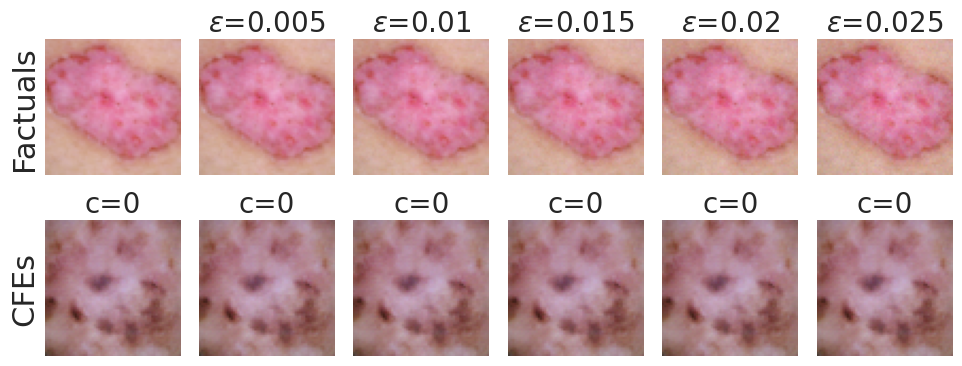

In [50]:
ind = 7
factuals_pert_list = [denorm(factuals[ind]).cpu()] + [factuals_pert[noise_level][ind] for noise_level in noise_levels]
cfes_pert_list = [cfes[ind].cpu()] + [cfes_pert[noise_level][ind].detach().cpu() for noise_level in noise_levels]

plt.style.use("seaborn-v0_8")

n_rows = 2
n_cols = len(factuals_pert_list)

_, axs = plt.subplots(n_rows, n_cols, figsize=(10, 4), sharex=True, sharey=True)
for j in range(n_cols):
    # Factuals: already in [0, 1]
    factuals_pert_j = torch.Tensor(factuals_pert_list[j]).permute(1, 2, 0).numpy()
    axs[0, j].imshow(factuals_pert_j)
    if j > 0:
        noise = noise_levels[j - 1]
        axs[0, j].set_title('$\\epsilon$={}'.format(noise), fontsize=20)
    # print(factuals_pert_j.min(), factuals_pert_j.max())

    # CFEs: in [-1, 1] from generator, just denorm to [0, 1]
    cfe_vis = denorm(cfes_pert_list[j]).permute(1, 2, 0).detach().numpy()
    # print(cfe_vis.min(), cfe_vis.max())
    axs[1, j].imshow(cfe_vis)

    # Predictions: renorm for classifier only, not for display
    logits = baseline_classifier(renorm(cfes_pert_list[j].unsqueeze(0).to(device)))
    pred_class_ind = torch.argmax(logits, axis=1).item()
    axs[1, j].set_title(f'c={target_class if pred_class_ind == target_class_ind else pred_class_ind}', fontsize=20)
    
    if j == 0:
        axs[0, j].set_ylabel('Factuals', fontsize=22)
        axs[1, j].set_ylabel('CFEs', fontsize=22)

plt.tight_layout()
plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[])
plt.savefig(osp.join(save_dir, f'c3lt_multi_{target_class}_cfes_ind{ind}.png'), dpi=300)
plt.show()

In [52]:
def to_img(tensor):
    """(C, H, W) tensor → (H, W, C) numpy for imshow."""
    return tensor.permute(1, 2, 0).detach().cpu().numpy()
 
 
def compute_diff_mask(factual, cfe):
    """
    Compute a per-pixel difference mask between factual and CFE.
    Both inputs in [-1, 1]. Returns an RGB heatmap-ready (H, W) array in [0, 1].
    """
    diff = (cfe - factual).abs().mean(dim=0)  # average across channels → (H, W)
    # Normalize to [0, 1]
    if diff.max() > diff.min():
        diff = (diff - diff.min()) / (diff.max() - diff.min())
    return diff.detach().cpu().numpy()

def plot_multiple_samples(factuals, encoder, generator, cfes, labels,
                          classifier, renorm, target_class, target_class_ind,
                          n_samples=5, device='cuda', save_path=None):
    """
    Grid figure: n_samples rows × 4 columns.
    factuals, cfes: (N, C, H, W) tensors in [-1, 1]
    """
    n = min(n_samples, factuals.shape[0])
 
    fig, axs = plt.subplots(n, 4, figsize=(12, 3 * n))
    if n == 1:
        axs = axs[np.newaxis, :]
 
    col_titles = ['Factual', 'Reconstruction', 'CFE', 'Difference Mask']
 
    for i in range(n):
        f_i = factuals[i].cpu()
        c_i = cfes[i].cpu()
 
        # Reconstruction
        with torch.no_grad():
            z = encoder(factuals[i].unsqueeze(0).to(device))
            # if z.dim() == 4 and (z.shape[2] != 1 or z.shape[3] != 1):
            #     import torch.nn.functional as F
            #     z = F.adaptive_avg_pool2d(z, 1)
            recon = generator(z).squeeze(0).cpu()
 
        diff_mask = compute_diff_mask(f_i, c_i)
 
        # Prediction on CFE
        with torch.no_grad():
            cfe_logits = classifier(renorm(cfes[i].unsqueeze(0).to(device)))
            cfe_pred = torch.argmax(cfe_logits, dim=1).item()
 
        # Plot
        axs[i, 0].imshow(to_img(denorm(f_i)))
        axs[i, 0].set_ylabel(f'c={labels[i].item()}', fontsize=12, rotation=0, labelpad=30)
 
        axs[i, 1].imshow(to_img(denorm(recon)))
 
        axs[i, 2].imshow(to_img(denorm(c_i)))
        axs[i, 2].set_title(f'pred={cfe_pred}' if i == 0 else '', fontsize=11)
 
        im = axs[i, 3].imshow(diff_mask, cmap='Grays', vmin=0, vmax=1)
 
        for j in range(4):
            axs[i, j].axis('off')
            if i == 0:
                axs[i, j].set_title(col_titles[j], fontsize=13, fontweight='medium')
 
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

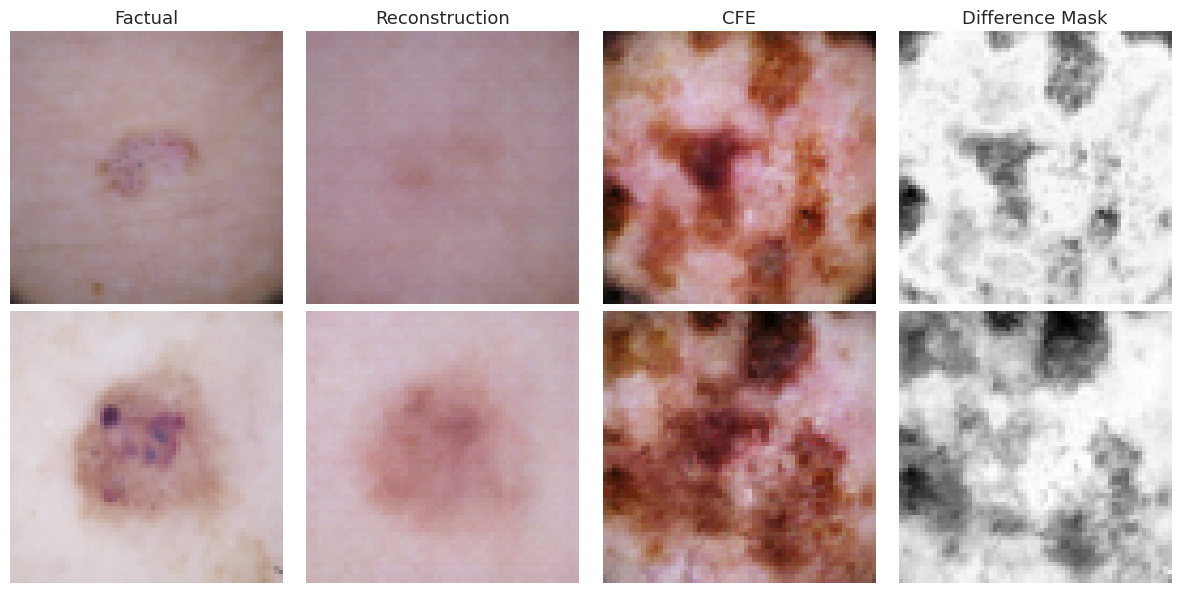

In [57]:
start, stop = 14, 17
plot_multiple_samples(
     factuals=factuals[start:stop], encoder=expl_model.encoder, generator=expl_model.generator,
     cfes=cfes[start:stop], labels=labels, device='cpu',
     classifier=baseline_classifier, renorm=renorm,
     target_class=target_class, target_class_ind=target_class_ind,
     n_samples=2, save_path=osp.join(save_dir, f'c3lt_derma_multi_grid_{start}_{stop}.png')
 )

In [58]:
instability_l1_list = []
ssim_list = []

for noise_level, cfe_pert_list in cfes_pert.items():
    # print('noise level:', noise_level)
    l1_temp = []
    ssim_temp = []
    for i in range(len(cfes)):
        cf = cfes[i].detach().cpu()
        cf_pert = cfe_pert_list[i].detach().cpu()

        if len(cf) == 0:
            continue
        if len(cf_pert) == 0:
            continue

        cf_tensor = torch.Tensor(cf)
        cf = cf_tensor.permute(1, 2, 0).flatten()

        cf_pert_tensor = torch.Tensor(cf_pert)
        cf_perturbed = cf_pert_tensor.permute(1, 2, 0).flatten()        

        l1_distance = sum(abs(cf - cf_perturbed)).item() 
        # print(i, l1_distance)
        l1_temp.append(l1_distance)

        ssim = calculate_ssim(cf_tensor.unsqueeze(0), cf_pert_tensor.unsqueeze(0)).item()
        ssim_temp.append(ssim)

    instability_l1_list.append(l1_temp)
    ssim_list.append(ssim_temp)
        


with open(osp.join(save_dir, f'derma_{target_class}_li_l1.pkl'), 'wb') as f:
    pickle.dump(instability_l1_list, f)

with open(osp.join(save_dir, f'derma_{target_class}_ssim.pkl'), 'wb') as f:
    pickle.dump(ssim_list, f)

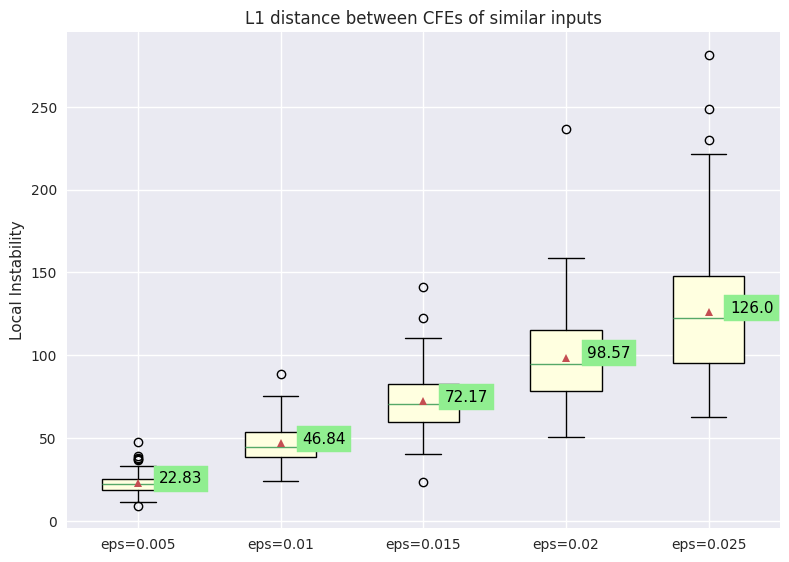

In [59]:
plt.style.use("seaborn-v0_8")


plot_boxplot(data=instability_l1_list, mean_values=np.round(np.mean(instability_l1_list, axis=1), 2),
             tick_labels=[f'eps={noise_level}' for noise_level in noise_levels],
             y_label='Local Instability', colors=['lightyellow'], title='L1 distance between CFEs of similar inputs')

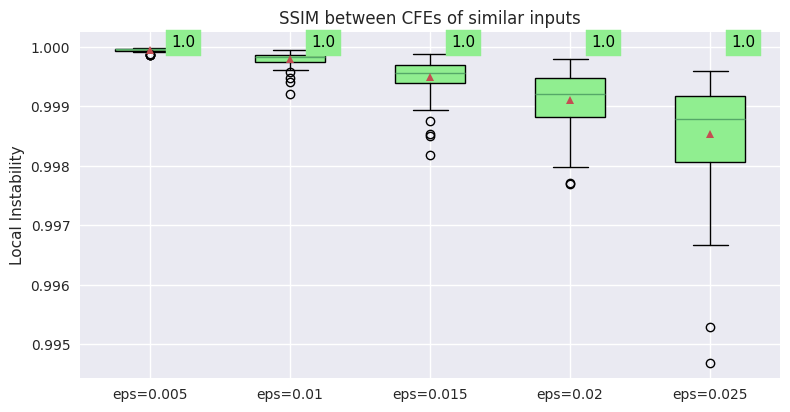

In [61]:
plt.rcParams['figure.figsize'] = [8, 4]

plot_boxplot(data=ssim_list, mean_values=np.round(np.mean(ssim_list, axis=1), 2),
             tick_labels=[f'eps={noise_level}' for noise_level in noise_levels],
             y_label='Local Instability', colors=['lightgreen'], title='SSIM between CFEs of similar inputs')

## Local Lipschitz Continuity

In [202]:
original_points = factuals 
original_cfes = cfes
print("Are the lengths of initial points (factuals) and CFEs generated for them equal :", len(original_cfes) == original_points.shape[0])


Are the lengths of initial points (factuals) and CFEs generated for them equal : True


In [203]:
i = 0
n_samples = 30
lip_estimates = []
noise_magnitude = 0.001

original_points = original_points.detach().cpu()
original_cfes = original_cfes.detach().cpu()
for original_point, original_cfe in tqdm(zip(original_points[:30], original_cfes[:30])):

    neighbor_points = perturb_sample(original_point, n_samples=n_samples, 
                                    epsilon=noise_magnitude, type='uniform', 
                                    channels_first=True).squeeze(0) 
    neighbor_points = torch.Tensor(neighbor_points).to(device)  
    neighbor_cfes = expl_model.get_counterfactuals(neighbor_points, labels).detach().cpu() 
    neighbor_points = neighbor_points.detach().cpu()
    

    lip_estimate = 0
    for m, p in tqdm(zip(neighbor_cfes, neighbor_points)):
        # lip = np.linalg.norm(original_cfe - m) / np.linalg.norm(original_point - p)
        num = np.linalg.norm((original_cfe - m).flatten(), ord=2) 
        denom = np.linalg.norm((original_point - p).flatten(), ord=2)
        lip = num / denom
        lip_estimate = max(lip, lip_estimate)

    lip_estimates.append(lip_estimate.item())
    i += 1

30it [00:00, 8378.00it/s]
30it [00:00, 9752.68it/s]
30it [00:00, 10426.68it/s]
30it [00:00, 9118.05it/s]
30it [00:00, 8963.46it/s]
30it [00:00, 12496.68it/s]
30it [00:00, 12344.66it/s]
30it [00:00, 9939.89it/s]
30it [00:00, 14093.76it/s]
30it [00:00, 12283.20it/s]
30it [00:00, 13277.32it/s]
30it [00:00, 11117.61it/s]
30it [00:00, 12188.02it/s]
30it [00:00, 13181.35it/s]
30it [00:00, 11600.36it/s]
30it [00:00, 12900.26it/s]
30it [00:00, 12956.05it/s]
30it [00:00, 10205.12it/s]
30it [00:00, 12012.33it/s]
30it [00:00, 12616.98it/s]
30it [00:00, 11708.30it/s]
30it [00:00, 13228.46it/s]
30it [00:00, 12712.58it/s]
30it [00:00, 12215.23it/s]
30it [00:00, 11843.86it/s]
30it [00:00, 12559.05it/s]
30it [00:00, 11428.62it/s]
30it [00:00, 12786.21it/s]
30it [00:00, 11415.14it/s]
30it [00:00, 12279.61it/s]
30it [00:04,  7.15it/s]


In [204]:
with open(osp.join(save_dir, f'derma_{target_class}_lle.pkl'), 'wb') as f:
        pickle.dump(lip_estimates, f)

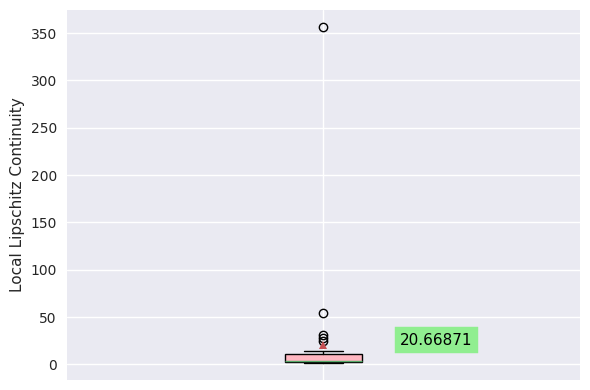

In [205]:
plt.rcParams['figure.figsize'] = [6, 4]
plot_boxplot(data=lip_estimates, mean_values=[np.round(np.mean(lip_estimates), 5)],
             tick_labels=[f''],
             y_label='Local Lipschitz Continuity', colors=['lightpink'], title='')

## Invalidation Rate

In [62]:
classifiers_weights_dir = r'/teamspace/studios/this_studio/CF-Robustness-Benchmark/notebooks/experiments/dermamnist_classification/multiclass/checkpoints/mc_4'

imgs = ds_builder.train_dataset.data.imgs  # (N, H, W, 3), uint8 [0, 255]
mean = imgs.mean(axis=(0, 1, 2)) / 255.0   # per-channel mean
std = imgs.std(axis=(0, 1, 2)) / 255.0  

test_loader.dataset.transform = A.Compose(
            [A.Normalize(mean=mean.tolist(), std=std.tolist())])

            
classifiers_list = []
for clf_weights in os.listdir(classifiers_weights_dir):
    cnn_perturbed = build_resnet50(**args.classifier_args)
    load_model_weights(model=cnn_perturbed, 
    weights_path=osp.join(classifiers_weights_dir, clf_weights), 
    lightning_used=False)
    cnn_perturbed.eval()
    classifiers_list.append(cnn_perturbed)
    # evaluate_classification_model(cnn_perturbed, 
    #                               dataloader=test_loader, 
    #                               num_classes=config.data.num_classes,
    #                               device=device)

In [63]:
validity_list = []
invalidation_rate_list = []
baseline_pred = torch.argmax(baseline_classifier(renorm(cfes)), axis=1)

for i, classifier in enumerate(classifiers_list):
    validity = 0
    invalidation_rate = 0
    total_found_cfs = 0
    
    classifier.eval()
    with torch.no_grad():
        classifier = classifier.to(device)
        alternative_pred = torch.argmax(classifier(renorm(cfes)), axis=1)
    
    invalidation_rate = np.where(baseline_pred.detach().cpu() != alternative_pred.detach().cpu())[0].shape[0] / baseline_pred.shape[0]
    validity = np.where(alternative_pred.detach().cpu() == target_class_ind)[0].shape[0] / alternative_pred.shape[0]

    # invalidation_rate /= total_found_cfs
    invalidation_rate_list.append(invalidation_rate)
    validity_list.append(validity)
    print(f'Model {i}: IR={invalidation_rate}, validity={validity}')

print('Average IR : {:.3f} +- {:.3f}'.format(np.mean(invalidation_rate_list), np.std(invalidation_rate_list)))
print('Average VaR : {:.3f} +- {:.3f}'.format(np.mean(validity_list), np.std(validity_list)))

Model 0: IR=0.012048192771084338, validity=1.0
Model 1: IR=0.0, validity=0.9879518072289156
Model 2: IR=0.012048192771084338, validity=0.9759036144578314
Model 3: IR=0.024096385542168676, validity=0.9879518072289156
Model 4: IR=0.0, validity=0.9879518072289156
Model 5: IR=0.0, validity=0.9879518072289156
Model 6: IR=0.0, validity=0.9879518072289156
Model 7: IR=0.0, validity=0.9879518072289156
Model 8: IR=0.012048192771084338, validity=1.0
Model 9: IR=0.0, validity=0.9879518072289156
Average IR : 0.006 +- 0.008
Average VaR : 0.989 +- 0.006


## Stability


In [ ]:
k = 1000
std = 0.1

average_stability_list = []
for i, classifier in enumerate(classifiers_list):
    stability_list = []
    for cfe in cfes:

        cfe = torch.Tensor(cfe).unsqueeze(0).detach().cpu()
        print(cfe.min(), cfe.max())
        cfe_norm = denorm(cfe)
        print(cfe_norm.min(), cfe_norm.max())
        cfe_sampled = perturb_sample(cfe_norm, n_samples=k, type='normal', 
                                    epsilon=0, std=std, channels_first=True)
        cfe_sampled = torch.Tensor(cfe_sampled).squeeze(0)

        # Convert back to [-1, 1] for renorm
        cfe_sampled_gan = cfe_sampled * 2 - 1
        print(cfe_sampled_gan.min(), cfe_sampled_gan.max())


        with torch.no_grad():
            cfe_renorm = renorm(cfe).to(device)
            print(cfe_renorm.min(), cfe_renorm.max())
            cf_logits = classifier(cfe_renorm)
            cf_probabilities = F.softmax(cf_logits, dim=-1)[:, target_class_ind]

            cf_sampled_logits = classifier(renorm(cfe_sampled_gan).to(device))
            cf_sampled_probabilities = F.softmax(cf_sampled_logits, dim=-1)[:, target_class_ind]
        
        model_variance = abs(cf_probabilities - cf_sampled_probabilities)

        stability = (cf_sampled_probabilities - model_variance).mean()
        stability_list.append(stability.item())

    avg_i_stability = np.mean(stability_list)
    print(f'Stability of the model {i}: {round(avg_i_stability.item(), 3)} +- {round(np.std(stability_list).item(), 2)}')
    average_stability_list.append(avg_i_stability) 

tensor(-0.9982) tensor(0.8602)
tensor(0.0009) tensor(0.9301)


In [ ]:
k = 100
std = 0.1
batch_size = 10

cfes_tensor = torch.stack([torch.Tensor(cfe) for cfe in cfes[:5]])
n_cfes = len(cfes)

# Find valid CFEs
with torch.no_grad():
    all_preds = []
    for j in range(0, n_cfes, batch_size):
        batch = cfes_tensor[j:j+batch_size].to(device)
        logits = baseline_classifier(renorm(batch))
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.cpu())
    baseline_preds = torch.cat(all_preds)

valid_mask = baseline_preds == target_class_ind
valid_indices = torch.where(valid_mask)[0]
print(f'Valid CFEs: {len(valid_indices)}/{n_cfes} ({100*len(valid_indices)/n_cfes:.1f}%)')

# Stability calculation
average_stability_list = []

for i, classifier in enumerate(classifiers_list):
    classifier.eval()
    classifier = classifier.to(device)
    stability_list = []

    for idx in tqdm(valid_indices, desc=f'Classifier {i+1}/{len(classifiers_list)}'):
        cfe = cfes_tensor[idx].unsqueeze(0)

        # Baseline probability for this CFE
        with torch.no_grad():
            cf_prob = F.softmax(classifier(renorm(cfe).to(device)), dim=-1)[:, target_class_ind].cpu().item()

        # Perturb in [0,1], convert back to [-1,1]
        cfe_01 = denorm(cfe).detach().numpy()
        cfe_sampled_01 = perturb_sample(cfe_01, n_samples=k, type='normal',
                                         epsilon=0, std=std, channels_first=True)
        cfe_sampled_gan = torch.Tensor(cfe_sampled_01).squeeze(0) * 2 - 1

        sampled_probs = []
        with torch.no_grad():
            for j in range(0, k, batch_size):
                b = cfe_sampled_gan[j:j+batch_size].to(device)
                probs = F.softmax(classifier(renorm(b)), dim=-1)[:, target_class_ind]
                sampled_probs.append(probs.cpu())
        sampled_probs = torch.cat(sampled_probs)

        model_variance = (cf_prob - sampled_probs).abs()
        stability = (sampled_probs - model_variance).mean().item()
        stability_list.append(stability)

    avg = np.mean(stability_list)
    std_val = np.std(stability_list)
    print(f'Classifier {i+1}: Stability = {avg:.3f} +- {std_val:.2f}')
    average_stability_list.append(avg)

print(f'\nOverall: {np.mean(average_stability_list):.3f} +- {np.std(average_stability_list):.3f}')

Valid CFEs: 5/78 (6.4%)


Classifier 1/10:   0%|          | 0/5 [00:00<?, ?it/s]

Classifier 1/10:  40%|████      | 2/5 [18:55<28:18, 566.02s/it]

In [25]:
print('Average stability : {:.3f} +- {:.3f}'.format(np.mean(average_stability_list).round(3), 
                                            np.std(average_stability_list).round(3))) 

Average stability : 0.995 +- 0.004


## LOF

In [30]:
from src.evaluation.lof import estimate_anom_cfe_in_target_class

In [31]:
cfes_array = cfes.detach().cpu().numpy()

In [32]:
target_class_ascores, target_class_classes = estimate_anom_cfe_in_target_class(5, [1], -1.1, test_loader, cfes_array)
print('Average negative LOF (the lower values the more anomaluous): {:.3f} +- {:.3f}'.format(np.mean(target_class_ascores), 
                                                                                            np.std(target_class_ascores)))

Average negative LOF (the lower values the more anomaluous): -1.016 +- 0.028


In [33]:
anomaly_scores, anomaly_classes = estimate_anom_cfe_in_target_class(5, [0, 1], -1.1, test_loader, cfes_array)
print('Average negative LOF (the lower values the more anomaluous): {:.3f} +- {:.3f}'.format(np.mean(anomaly_scores), np.std(anomaly_scores)))

Average negative LOF (the lower values the more anomaluous): -1.019 +- 0.029


In [65]:
with open(osp.join(save_dir, f'fmnist_{target_class}_ir_var_rs_lof.pkl'), 'wb') as f:
    pickle.dump({'ir': (np.mean(invalidation_rate_list), np.std(invalidation_rate_list)),
                'var': (np.mean(validity_list), np.std(validity_list)),
                'rs': (np.mean(average_stability_list), np.std(average_stability_list)),
                'lof_target_class': (np.mean(target_class_ascores), np.std(target_class_ascores)),
                'lof_test_set': (np.mean(anomaly_scores), np.std(anomaly_scores))
                }, f)

In [66]:
with open(osp.join(save_dir, f'fmnist_{target_class}_ir_var_rs_lof.pkl'), 'rb') as f:
    r = pickle.load(f)

In [67]:
r

{'ir': (np.float64(0.007999999999999998), np.float64(0.004)),
 'var': (np.float64(0.994), np.float64(0.008000000000000007)),
 'rs': (np.float64(0.9821584345996379), np.float64(0.006756975385459651)),
 'lof_target_class': (np.float32(-1.0183502), np.float32(0.03096331)),
 'lof_test_set': (np.float32(-1.0216428), np.float32(0.033483483))}